In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import sys
sys.path.insert(0, '/glade/u/home/dcalhoun/censuswxindex')
from censuswxindex import aggregate as wxagg

In [2]:
# Shapefile for aggregation
scratch = '/glade/derecho/scratch/dcalhoun'
shapefile_path = scratch + '/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'

In [3]:
# Build our list of forecast files
dates = pd.date_range(start='2020-01-01', end='2024-01-01', freq='12h')
lead_times = [12, 24, 36]

fc_files = []
for init_time in dates:
    for lead_time in lead_times:
        date_str = init_time.strftime("%Y%m%d%H%M")
        year = date_str[:4]
        month = date_str[4:6]
        day = date_str[6:8]
        hour = date_str[8:]
        fc_path = glob.glob(scratch + f'/ecmwf/ifs/fc/0.125/2t/{hour}/{lead_time}/{year}/{month}/*{day}.nc')
        # Only append if a file was found (avoid empty file lists)
        if fc_path:
            fc_files.append((fc_path[0], str(init_time), lead_time))
n_files = len(fc_files)
print(n_files)

5846


In [4]:
# Select a few random samples to aggregate
idxs = [int(x) for x in np.random.choice(n_files, size=4, replace=False)]
for idx in idxs:
    print(fc_files[idx])

('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/24/2022/09/ifs_fc_2t_0000_24_20220914.nc', '2022-09-14 00:00:00', 24)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/12/2021/12/ifs_fc_2t_1200_12_20211212.nc', '2021-12-12 12:00:00', 12)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/12/2021/07/ifs_fc_2t_1200_12_20210706.nc', '2021-07-06 12:00:00', 12)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/24/2022/03/ifs_fc_2t_0000_24_20220301.nc', '2022-03-01 00:00:00', 24)


In [ ]:
# Define our GeoAggregator with our shapefile and grid
# Calculates a weightmap of overlaps between grid boxes and polygons
geo_agg = wxagg.GeoAggregator(shapefile_path=shapefile_path, grid_path=fc_files[0][0])

In [6]:
geo_agg

GeoAggregator
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [7]:
# Build our ForecastAggregator from our forecast files
# We use the weightmap we already calculated
fc_agg = wxagg.ForecastAggregator.from_GeoAggregator(geo_agg, forecast_files=[fc_files[idx] for idx in idxs], var_name="t2m")

In [8]:
fc_agg

ForecastAggregator
n_files: 4
init_times:
	2021-07-06 12:00:00
	2021-12-12 12:00:00
	2022-03-01 00:00:00
	2022-09-14 00:00:00
lead_times: [12, 24]
var_name: 't2m'
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [9]:
# Run the aggregation to build a data table of our forecast data
df_fc = fc_agg.build_data_table()

In [10]:
df_fc

,geo_id,valid_time,init_time,lead_time,t2m
0,01001,2022-09-15,2022-09-14,24,297.188434
1,01003,2022-09-15,2022-09-14,24,298.152930
2,01005,2022-09-15,2022-09-14,24,297.872655
3,01007,2022-09-15,2022-09-14,24,297.283988
4,01009,2022-09-15,2022-09-14,24,296.990131
...,...,...,...,...,...
12431,56037,2022-03-02,2022-03-01,24,275.946641
12432,56039,2022-03-02,2022-03-01,24,274.852993
12433,56041,2022-03-02,2022-03-01,24,278.089122
12434,56043,2022-03-02,2022-03-01,24,282.403075


In [11]:
# Save our aggregated feature
fc_agg.save_data_table("test_fc.csv")

In [12]:
# Statistics by valid time
df_fc.groupby('valid_time').t2m.describe()

,count,mean,std,min,25%,50%,75%,max
valid_time,,,,,,,,
2021-07-07,3109.0,300.281187,3.667909,283.622729,298.443460,300.937069,302.423717,316.011546
2021-12-13,3109.0,278.606872,4.724971,265.779563,275.480239,278.056058,281.073077,299.753348
2022-03-02,3109.0,283.277716,6.214857,260.285498,279.831703,284.157861,287.667276,301.783996
2022-09-15,3109.0,296.103889,4.324876,279.334831,293.394983,296.075161,299.017387,306.326465


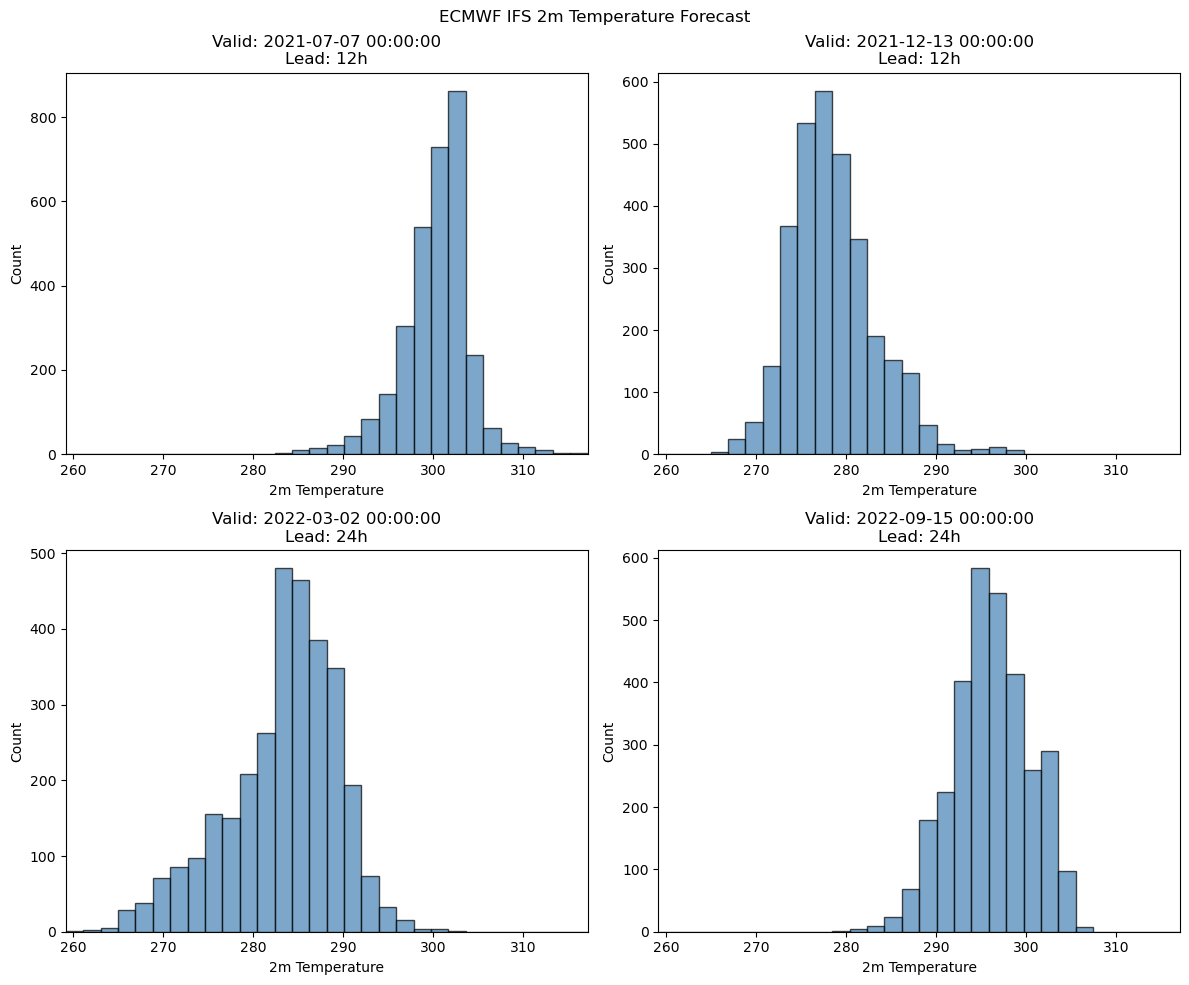

In [13]:
# Plot temperature histograms by valid time
valid_times = sorted(df_fc['valid_time'].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
bins = 30

tmin = df_fc['t2m'].min()
tmax = df_fc['t2m'].max()
# Add padding so bin edge is not at the very edge of the frame
padding = 0.02 * (tmax - tmin)
tmin_pad = tmin - padding
tmax_pad = tmax + padding

bin_edges = np.linspace(tmin_pad, tmax_pad, bins + 1)

for ax, vt in zip(axes, valid_times):
    sub = df_fc[df_fc['valid_time'] == vt]
    ax.hist(sub['t2m'], bins=bin_edges, color='steelblue', edgecolor='k', alpha=0.7)
    ax.set_title(f'Valid: {vt}\nLead: {sub['lead_time'].iloc[0]}h')
    ax.set_xlabel('2m Temperature')
    ax.set_ylabel('Count')
    ax.set_xlim([tmin_pad, tmax_pad])

plt.suptitle('ECMWF IFS 2m Temperature Forecast')
plt.tight_layout()
plt.show()

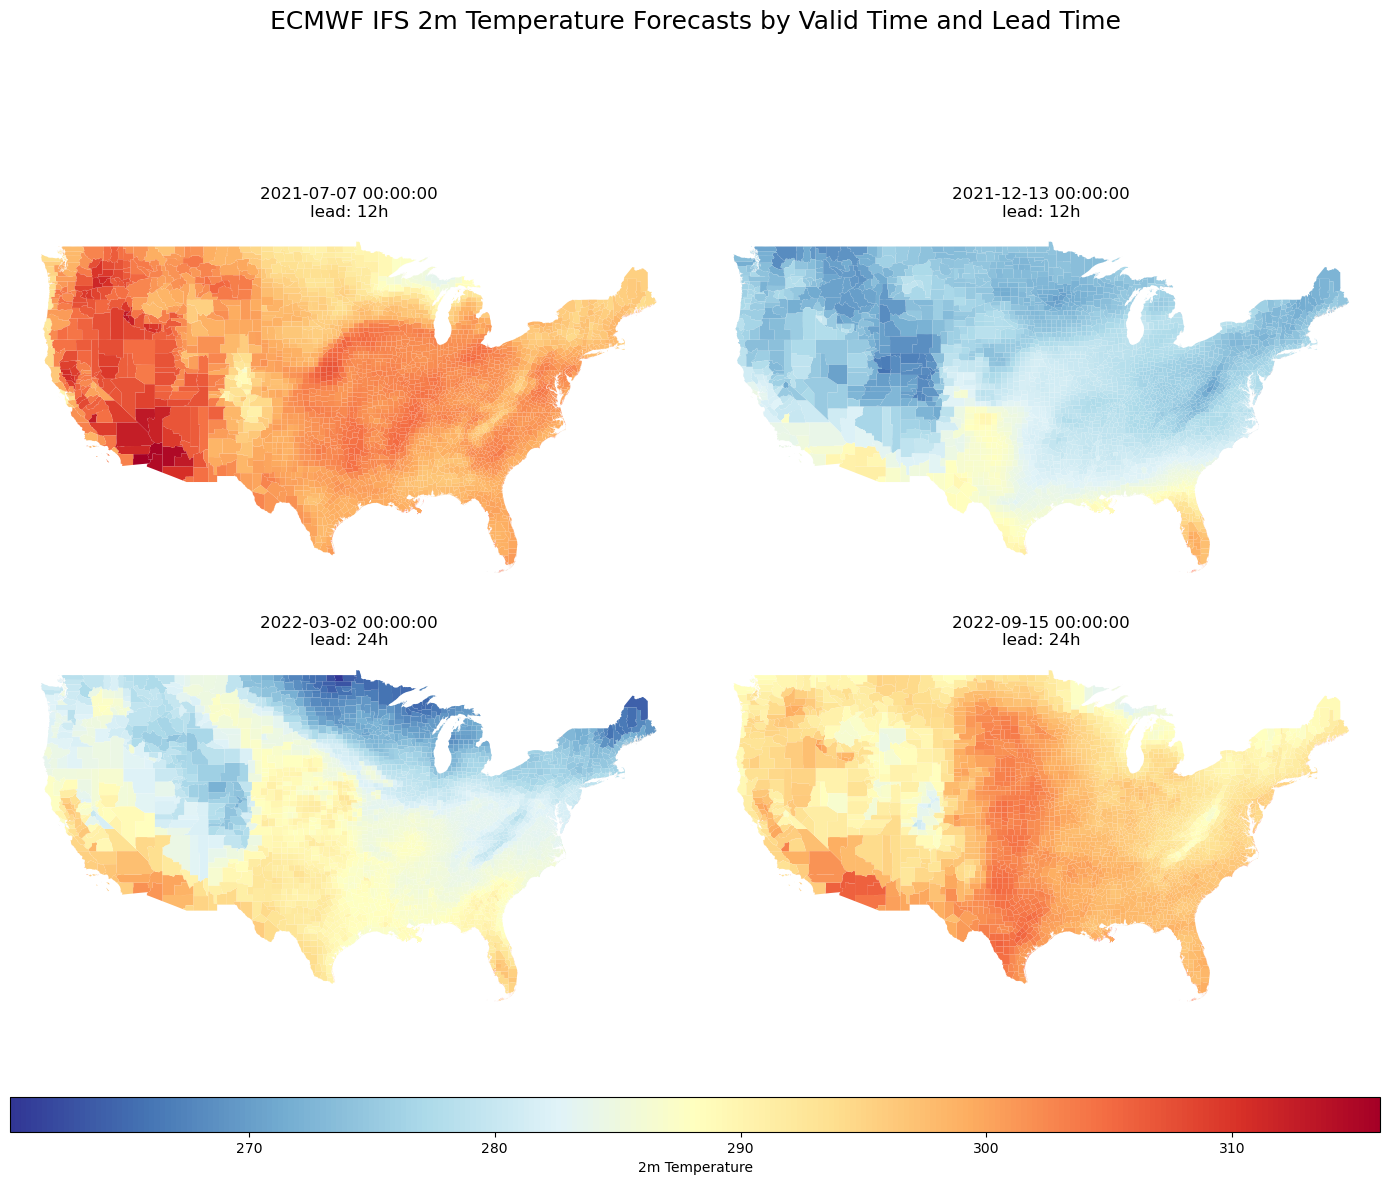

In [14]:
# Plot temperature maps by valid time
fc_agg.shapefile.rename(columns={'GEOID': 'geo_id'}, inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

vmin, vmax = df_fc['t2m'].min(), df_fc['t2m'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = 'RdYlBu_r'

valid_times = sorted(df_fc['valid_time'].unique())
for ax, valid_time in zip(axes, valid_times):
    sub = df_fc[df_fc['valid_time'] == valid_time]
    gdf_plot = fc_agg.shapefile.merge(sub[['geo_id', 't2m']], on='geo_id', how='inner')
    gdf_plot.plot(ax=ax, column='t2m', cmap=cmap, norm=norm)
    lead_val = sub['lead_time'].iloc[0]
    ax.set_title(f'{valid_time}\nlead: {lead_val}h')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.suptitle(
    'ECMWF IFS 2m Temperature Forecasts by Valid Time and Lead Time', 
    fontsize=18, 
    y=0.90  # Move title closer to panels
)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # Adjust for space at bottom for colorbar and a bit at top for title

fig.colorbar(
    sm,
    ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.04,
    pad=0.07,
    aspect=40,
    label='2m Temperature'
)
plt.show()